Ahmed Bilal Azhar
Roll No: 23I-2581
Section: DS-A

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.05)
main_color = "#4C72B0"
cat_palette = "Set2"

data = pd.read_csv("Sample_-_Superstore.csv", encoding="latin1")
data = data.rename(columns={"Order Date": "order_date", "Region": "region", "Category": "category", "Sub-Category": "subcategory", "Discount": "discount", "Profit": "profit", "Sales": "sales", "Quantity": "quantity"})
data["order_date"] = pd.to_datetime(data["order_date"])
data.head()

,Row ID,Order ID,order_date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,region,Product ID,category,subcategory,Product Name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


##### Task 1

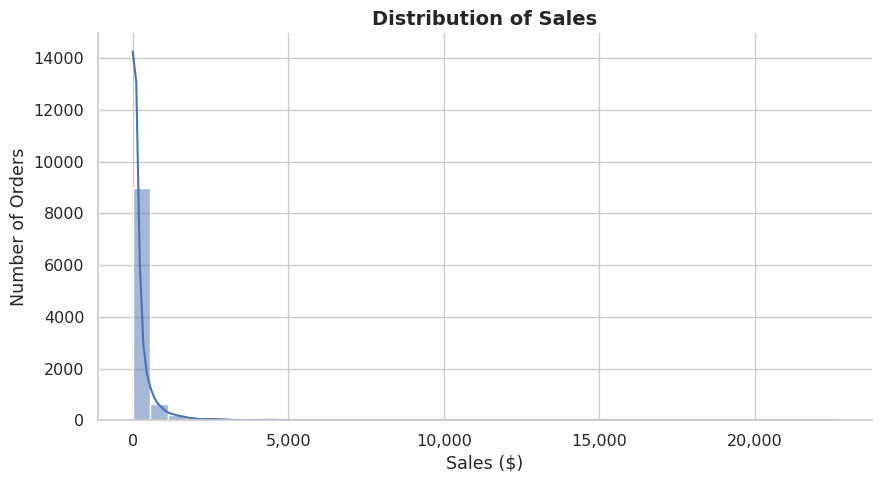

In [2]:
plt.figure(figsize=(9,5))
sns.histplot(data["sales"], kde=True, bins=40, color=main_color, edgecolor="white")
plt.title("Distribution of Sales", fontsize=14, fontweight="bold")
plt.xlabel("Sales ($)")
plt.ylabel("Number of Orders")
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
sns.despine()
plt.tight_layout()
plt.show()

In [3]:
skew_val = data["sales"].skew()
mean_val = data["sales"].mean()
median_val = data["sales"].median()
print("Skewness:", skew_val)
print("Mean:", mean_val)
print("Median:", median_val)

Skewness: 12.97275234181623
Mean: 229.85800083049827
Median: 54.489999999999995


In [4]:
if skew_val > 0:
    print("The sales column is right skewed since the mean is much bigger than the median, so a lot of high sales values are pulling the mean up and it does not represent the typical order well.")
elif skew_val < 0:
    print("The sales column is left skewed since the mean is smaller than the median.")
else:
    print("The sales column is roughly symmetric so the mean is a fine summary here.")

The sales column is right skewed since the mean is much bigger than the median, so a lot of high sales values are pulling the mean up and it does not represent the typical order well.


##### Task 2

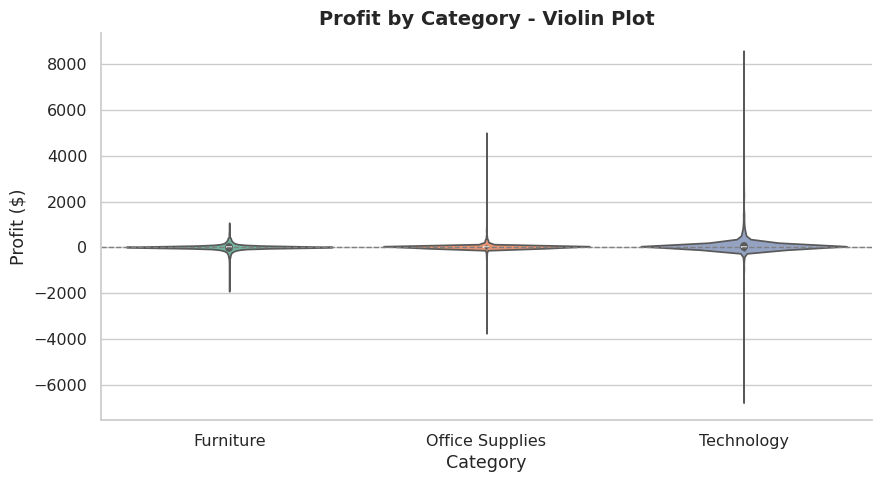

In [5]:
cat_order = ["Furniture", "Office Supplies", "Technology"]

plt.figure(figsize=(9,5))
sns.violinplot(data=data, x="category", y="profit", order=cat_order, hue="category", palette=cat_palette, legend=False)
plt.title("Profit by Category - Violin Plot", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Profit ($)")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
sns.despine()
plt.tight_layout()
plt.show()

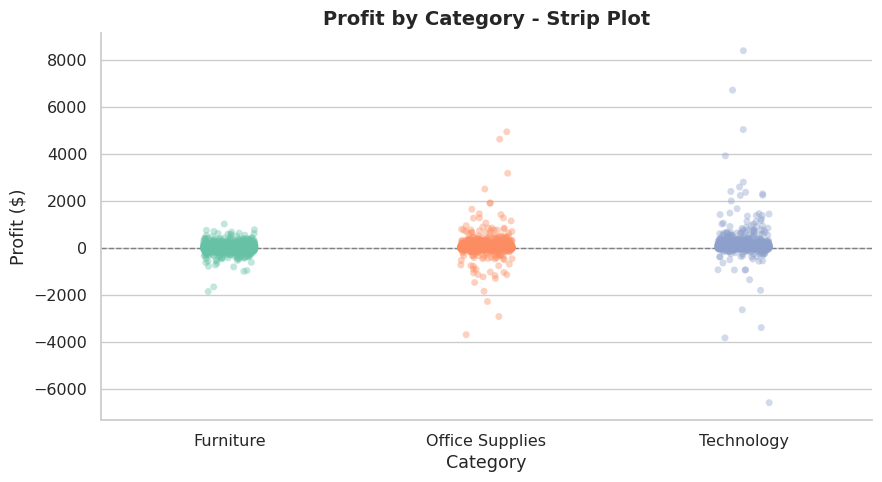

In [6]:
plt.figure(figsize=(9,5))
sns.stripplot(data=data, x="category", y="profit", order=cat_order, hue="category", jitter=True, alpha=0.4, palette=cat_palette, legend=False)
plt.title("Profit by Category - Strip Plot", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Profit ($)")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
sns.despine()
plt.tight_layout()
plt.show()

In [7]:
print("The violin plot reveals this better since it draws the actual estimated density shape. It shows Technology has a much wider spread with long thin tails stretching to both big profits and big losses, while Furniture and Office Supplies stay tightly bunched close to zero. In the strip plot that same spread just looks like a scatter of overlapping dots and is harder to read at this scale.")

The violin plot reveals this better since it draws the actual estimated density shape. It shows Technology has a much wider spread with long thin tails stretching to both big profits and big losses, while Furniture and Office Supplies stay tightly bunched close to zero. In the strip plot that same spread just looks like a scatter of overlapping dots and is harder to read at this scale.


##### Task 3

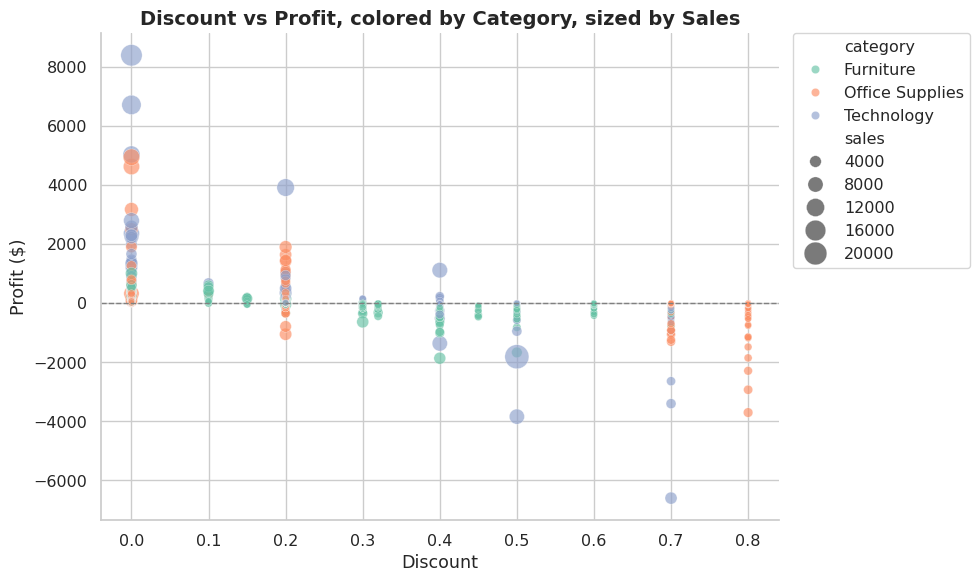

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x="discount", y="profit", hue="category", size="sales", sizes=(20,300), alpha=0.65, palette=cat_palette, edgecolor="white", linewidth=0.3)
plt.title("Discount vs Profit, colored by Category, sized by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
sns.despine()
plt.tight_layout()
plt.show()

In [9]:
print("The biggest losses only show up as large bubbles at high discount values, mostly in the Technology category, meaning it is high value Technology orders sold at a steep discount that cause the worst losses, a pattern the size encoding makes visible that a plain scatter would not show.")

The biggest losses only show up as large bubbles at high discount values, mostly in the Technology category, meaning it is high value Technology orders sold at a steep discount that cause the worst losses, a pattern the size encoding makes visible that a plain scatter would not show.


##### Task 4

In [10]:
numeric_cols = data[["sales", "quantity", "discount", "profit"]]
pearson_corr = numeric_cols.corr(method="pearson")
spearman_corr = numeric_cols.corr(method="spearman")
print(pearson_corr.round(3))
print(spearman_corr.round(3))

          sales  quantity  discount  profit
sales     1.000     0.201    -0.028   0.479
quantity  0.201     1.000     0.009   0.066
discount -0.028     0.009     1.000  -0.219
profit    0.479     0.066    -0.219   1.000
          sales  quantity  discount  profit
sales     1.000     0.327    -0.057   0.518
quantity  0.327     1.000    -0.001   0.234
discount -0.057    -0.001     1.000  -0.543
profit    0.518     0.234    -0.543   1.000


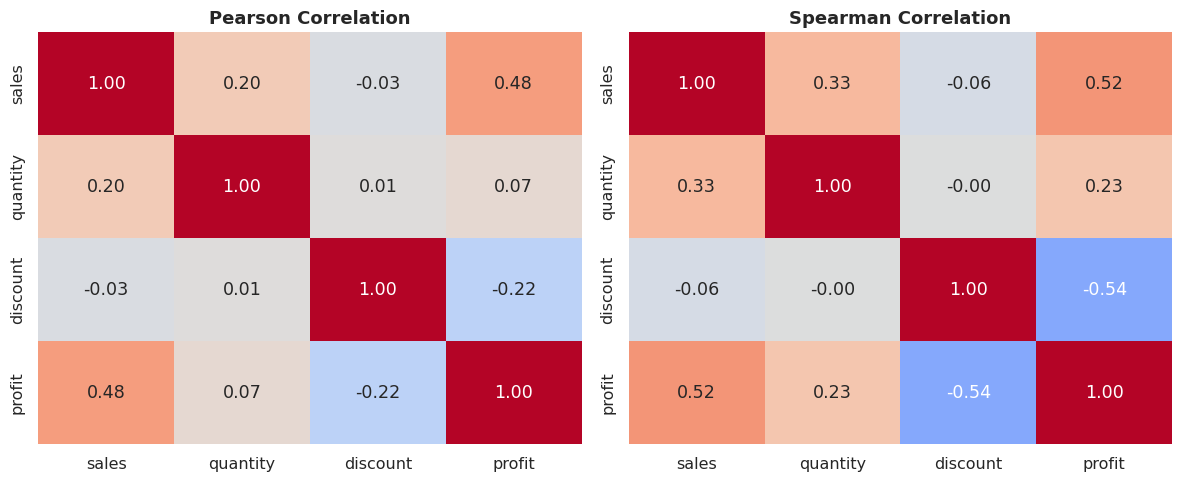

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title("Pearson Correlation", fontsize=13, fontweight="bold")
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1], cbar=False)
axes[1].set_title("Spearman Correlation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
cols = numeric_cols.columns
max_diff = 0
col_a = ""
col_b = ""
for i in range(len(cols)):
    for j in range(len(cols)):
        if i < j:
            diff = abs(pearson_corr.iloc[i, j] - spearman_corr.iloc[i, j])
            if diff > max_diff:
                max_diff = diff
                col_a = cols[i]
                col_b = cols[j]
print("Biggest disagreement is between:", col_a, "and", col_b)
print("Difference:", max_diff)

Biggest disagreement is between: discount and profit
Difference: 0.32386272585885323


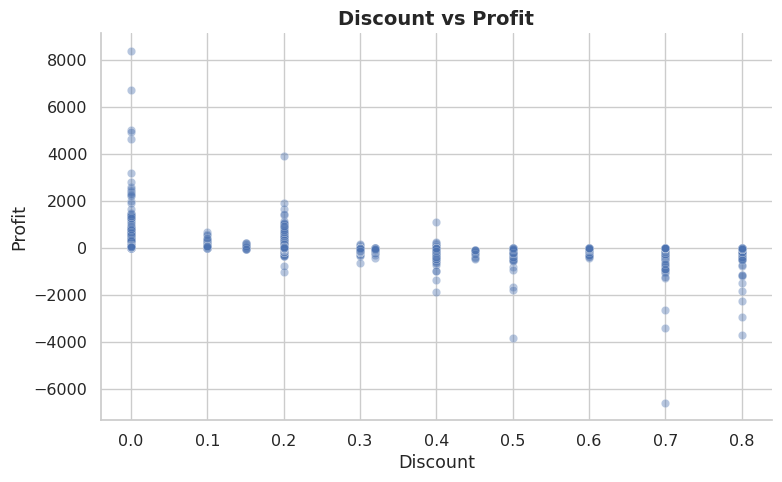

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x=col_a, y=col_b, alpha=0.4, color=main_color, edgecolor="white", linewidth=0.3)
plt.title(col_a.title() + " vs " + col_b.title(), fontsize=14, fontweight="bold")
plt.xlabel(col_a.title())
plt.ylabel(col_b.title())
sns.despine()
plt.tight_layout()
plt.show()

In [14]:
print("Pearson is much weaker here than Spearman because the discount to profit relationship is not a straight line, a few orders with very high discounts drop into huge losses and pull the linear correlation down, while Spearman only looks at rank order so it picks up the steady monotonic trend more clearly. This is only a correlation and does not prove that discount alone causes lower profit, other factors like category and quantity could also be driving it.")

Pearson is much weaker here than Spearman because the discount to profit relationship is not a straight line, a few orders with very high discounts drop into huge losses and pull the linear correlation down, while Spearman only looks at rank order so it picks up the steady monotonic trend more clearly. This is only a correlation and does not prove that discount alone causes lower profit, other factors like category and quantity could also be driving it.


##### Task 5

In [15]:
pivot = pd.pivot_table(data, index="region", columns="category", values="sales", aggfunc="sum", margins=True)
print(pivot.round(0))

category  Furniture  Office Supplies  Technology        All
region                                                     
Central    163797.0         167026.0    170416.0   501240.0
East       208291.0         205516.0    264974.0   678781.0
South      117299.0         125651.0    148772.0   391722.0
West       252613.0         220853.0    251992.0   725458.0
All        742000.0         719047.0    836154.0  2297201.0


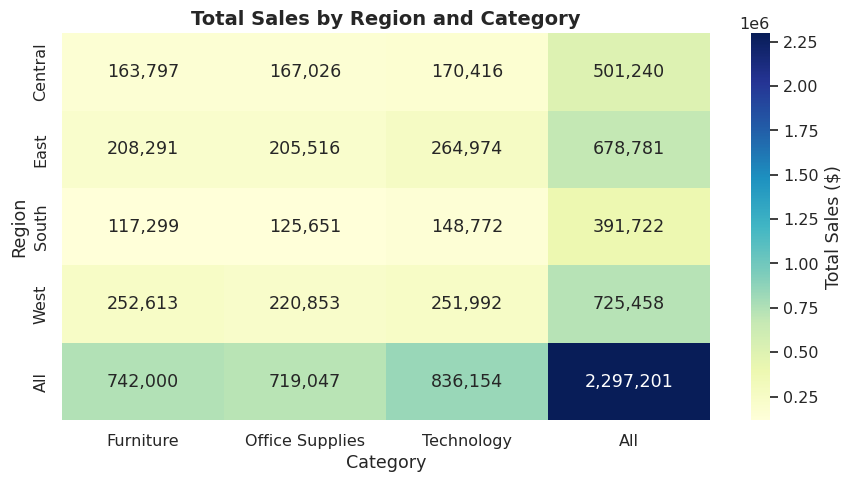

In [16]:
plt.figure(figsize=(9,5))
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="YlGnBu", cbar_kws={"label": "Total Sales ($)"})
plt.title("Total Sales by Region and Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

In [17]:
pivot_no_margin = pivot.drop("All", axis=0).drop("All", axis=1)
max_val = pivot_no_margin.values.max()
max_pos = pivot_no_margin.stack().idxmax()
print("The combination that brings in the most revenue is", max_pos[0], "region with", max_pos[1], "at", max_val)

The combination that brings in the most revenue is East region with Technology at 264973.981


##### Task 6

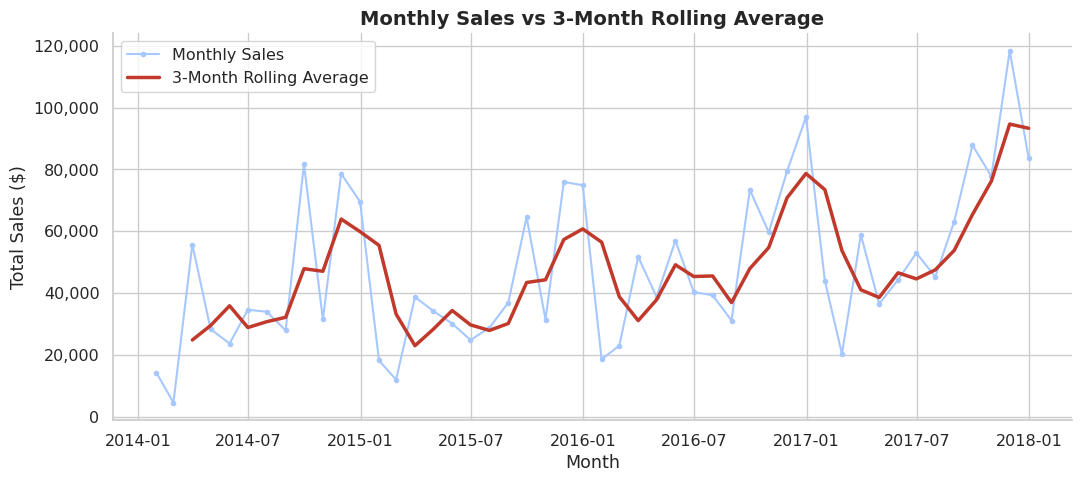

In [18]:
data_indexed = data.set_index("order_date")
monthly = data_indexed["sales"].resample("ME").sum()
rolling = monthly.rolling(window=3).mean()

plt.figure(figsize=(11,5))
plt.plot(monthly.index, monthly.values, label="Monthly Sales", color="#a6c8ff", linewidth=1.5, marker="o", markersize=3)
plt.plot(rolling.index, rolling.values, label="3-Month Rolling Average", color="#c0392b", linewidth=2.5)
plt.title("Monthly Sales vs 3-Month Rolling Average", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [19]:
print("The raw monthly line jumps up and down a lot from one month to the next, but the rolling average smooths that out and shows sales generally climb through the year with a clear peak around November and December each year.")

The raw monthly line jumps up and down a lot from one month to the next, but the rolling average smooths that out and shows sales generally climb through the year with a clear peak around November and December each year.


##### Task 7

In [20]:
profit_list = []
for value in data["profit"]:
    if value > 0:
        profit_list.append("Profitable")
    else:
        profit_list.append("Not Profitable")
data["profit_status"] = profit_list

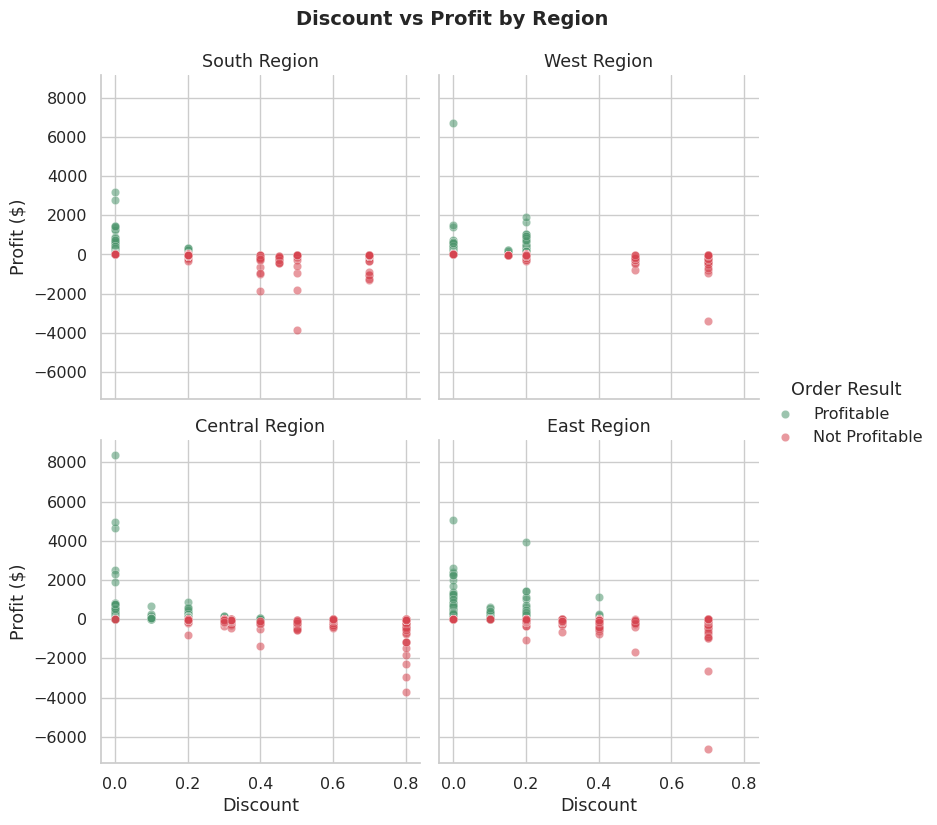

In [21]:
g = sns.FacetGrid(data, col="region", hue="profit_status", col_wrap=2, height=4, palette={"Profitable": "#4C956C", "Not Profitable": "#D64550"})
g.map(sns.scatterplot, "discount", "profit", alpha=0.55, edgecolor="white", linewidth=0.3)
g.add_legend(title="Order Result")
g.set_axis_labels("Discount", "Profit ($)")
g.set_titles("{col_name} Region")
g.fig.suptitle("Discount vs Profit by Region", fontsize=14, fontweight="bold", y=1.03)
plt.show()

In [22]:
print("Central stands out. Its panel already shows red, Not Profitable points at a 30 percent discount, while West stays almost entirely green, Profitable all the way up to a 50 percent discount. So the discount level where losses take over is clearly earlier for Central than for West.")

Central stands out. Its panel already shows red, Not Profitable points at a 30 percent discount, while West stays almost entirely green, Profitable all the way up to a 50 percent discount. So the discount level where losses take over is clearly earlier for Central than for West.


##### Task 8

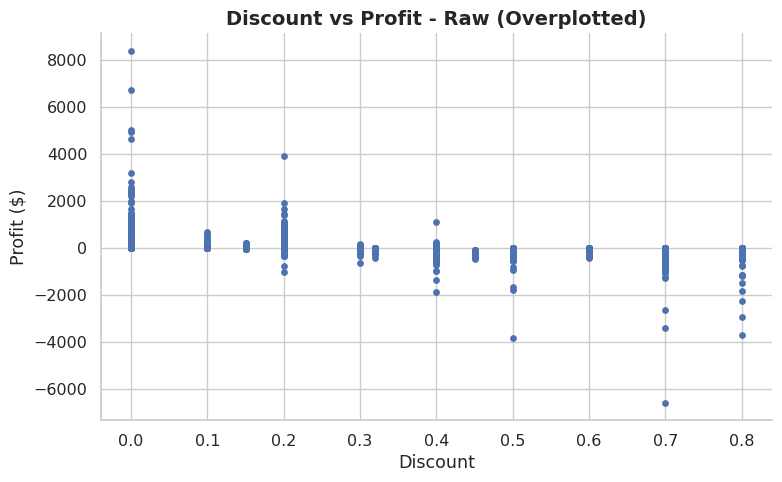

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(data["discount"], data["profit"], alpha=1, color=main_color, s=15)
plt.title("Discount vs Profit - Raw (Overplotted)", fontsize=14, fontweight="bold")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
sns.despine()
plt.tight_layout()
plt.show()

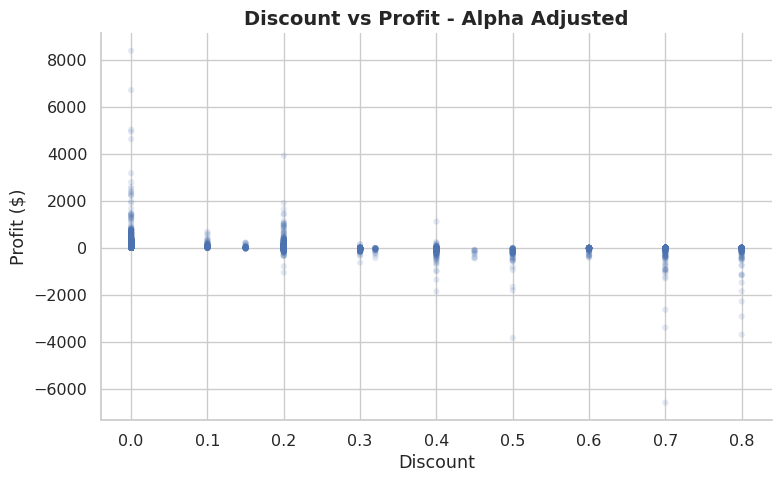

Alpha is used here instead of hexbin because there are under 10000 points which is not really a huge dataset, so just making the points transparent is enough to see where they pile up.


In [24]:
plt.figure(figsize=(8,5))
plt.scatter(data["discount"], data["profit"], alpha=0.15, color=main_color, s=20, edgecolor="none")
plt.title("Discount vs Profit - Alpha Adjusted", fontsize=14, fontweight="bold")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
sns.despine()
plt.tight_layout()
plt.show()
print("Alpha is used here instead of hexbin because there are under 10000 points which is not really a huge dataset, so just making the points transparent is enough to see where they pile up.")

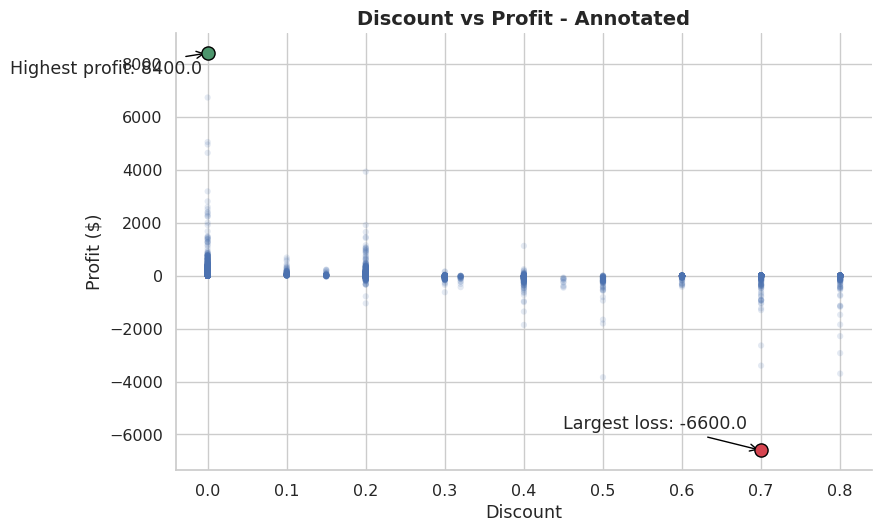

In [25]:
best_order = data.loc[data["profit"].idxmax()]
worst_order = data.loc[data["profit"].idxmin()]

plt.figure(figsize=(9,5.5))
plt.scatter(data["discount"], data["profit"], alpha=0.15, color=main_color, s=20, edgecolor="none")
plt.scatter([best_order["discount"]], [best_order["profit"]], color="#4C956C", s=90, edgecolor="black", zorder=5)
plt.scatter([worst_order["discount"]], [worst_order["profit"]], color="#D64550", s=90, edgecolor="black", zorder=5)
plt.annotate("Highest profit: " + str(round(best_order["profit"],0)), xy=(best_order["discount"], best_order["profit"]), xytext=(best_order["discount"] - 0.25, best_order["profit"] - 800), arrowprops=dict(arrowstyle="->", color="black"))
plt.annotate("Largest loss: " + str(round(worst_order["profit"],0)), xy=(worst_order["discount"], worst_order["profit"]), xytext=(worst_order["discount"] - 0.25, worst_order["profit"] + 800), arrowprops=dict(arrowstyle="->", color="black"))
plt.title("Discount vs Profit - Annotated", fontsize=14, fontweight="bold")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
sns.despine()
plt.tight_layout()
plt.show()